グレースケール画像に対して，以下のインパルス応答 $h[n_1, n_2]$ を持つLSIシステムの出力を
```scipy.signal.convolve2d``` を使って計算し，元の画像と並べて表示しなさい．
また，各 $h$ に対して $256 \times 256$ 点2次元DFTを施し，
各システムが低域通過フィルタと高域通過フィルタのどちらに相当するか，
それぞれの振幅スペクトルを基に考察しなさい．

1. 平均化フィルタ：$h = \dfrac{1}{9}\begin{pmatrix} 1 & 1 & 1 \\ 1 & 1 & 1 \\ 1 & 1 & 1 \end{pmatrix}$
2. ラプラシアンフィルタ：$h = \begin{pmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{pmatrix}$

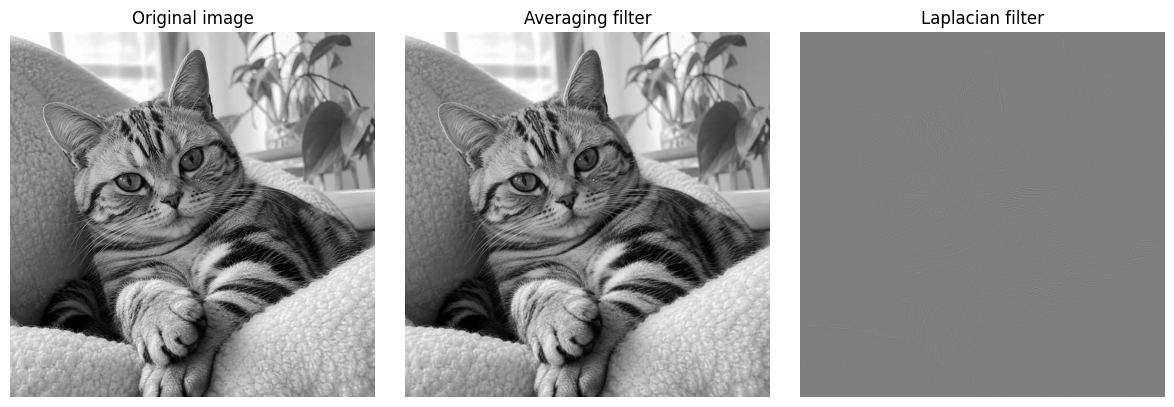

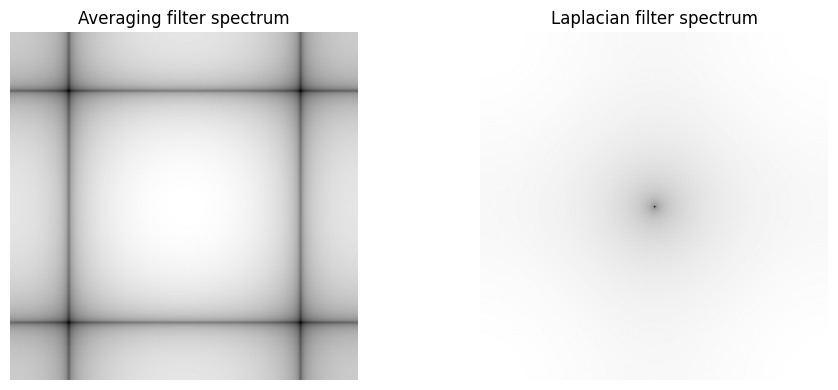

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# 入力画像パス
input_path = "/home/syamashita/initial-training-2026/syamashita-tu/chapter12/cat.png"

# 小さな正の数
epsilon = 1e-9

# グレースケール画像として読み込み
img = Image.open(input_path).convert("L")
x = np.asarray(img, dtype=np.float64)

# 1. 平均化フィルタ
h_avg = (1 / 9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.float64)

# 2. ラプラシアンフィルタ
h_lap = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float64)

# 畳み込み
# mode="same" により，出力画像サイズを入力画像と同じにする
# boundary="symm" により，画像端では対称拡張を使う
y_avg = convolve2d(x, h_avg, mode="same", boundary="symm")
y_lap = convolve2d(x, h_lap, mode="same", boundary="symm")

# フィルタの 256×256 点2次元DFT
H_avg = np.fft.fft2(h_avg, s=(256, 256))
H_lap = np.fft.fft2(h_lap, s=(256, 256))

# 直流成分を中心へ移動
H_avg_shift = np.fft.fftshift(H_avg)
H_lap_shift = np.fft.fftshift(H_lap)

# 対数スケールの振幅スペクトル
H_avg_db = 20 * np.log10(np.abs(H_avg_shift) + epsilon)
H_lap_db = 20 * np.log10(np.abs(H_lap_shift) + epsilon)

# 画像とフィルタ出力を表示
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(x, cmap="gray", vmin=0, vmax=255)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(y_avg, cmap="gray", vmin=0, vmax=255)
plt.title("Averaging filter")
plt.axis("off")

plt.subplot(1, 3, 3)
lap_abs_max = np.max(np.abs(y_lap))
plt.imshow(y_lap, cmap="gray", vmin=-lap_abs_max, vmax=lap_abs_max)
plt.title("Laplacian filter")
plt.axis("off")

plt.tight_layout()
plt.show()

# 各フィルタの振幅スペクトルを表示
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(H_avg_db, cmap="gray")
plt.title("Averaging filter spectrum")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(H_lap_db, cmap="gray")
plt.title("Laplacian filter spectrum")
plt.axis("off")

plt.tight_layout()
plt.show()

平均化フィルタの振幅スペクトルでは，中心付近の低周波成分が大きく，中心から離れた高周波成分は小さくなる．
そのため，平均化フィルタは低域通過フィルタに相当する．
画像に適用すると，細かい模様やエッジが弱まり，ぼかし効果が得られる．

ラプラシアンフィルタの振幅スペクトルでは，中心付近の低周波成分が小さく，中心から離れた高周波成分が強くなる．
そのため，ラプラシアンフィルタは高域通過フィルタに相当する．
画像に適用すると，滑らかな濃淡変化は抑えられ，輪郭やエッジなどの急激な変化が強調される．